Accuracy: 0.98

Classification Report:

              precision    recall  f1-score   support

           0     0.9000    1.0000    0.9474         9
           1     1.0000    0.9608    0.9800        51
           2     0.9756    1.0000    0.9877        40

    accuracy                         0.9800       100
   macro avg     0.9585    0.9869    0.9717       100
weighted avg     0.9812    0.9800    0.9801       100



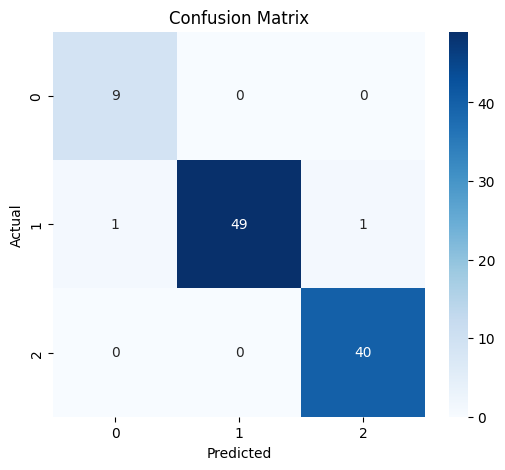

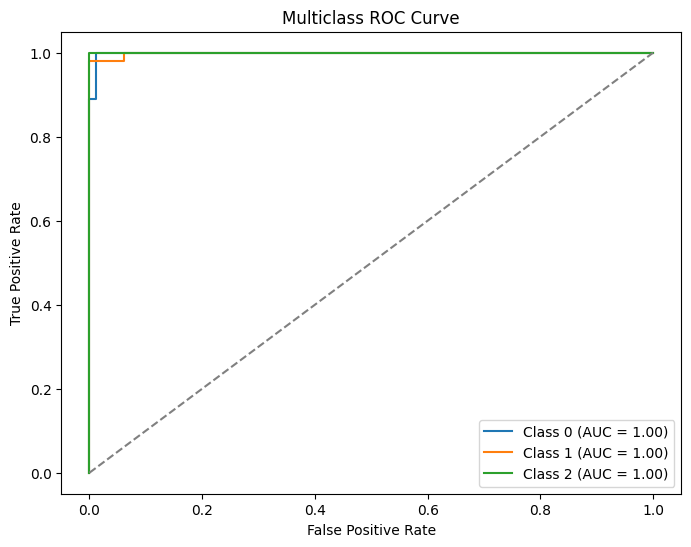

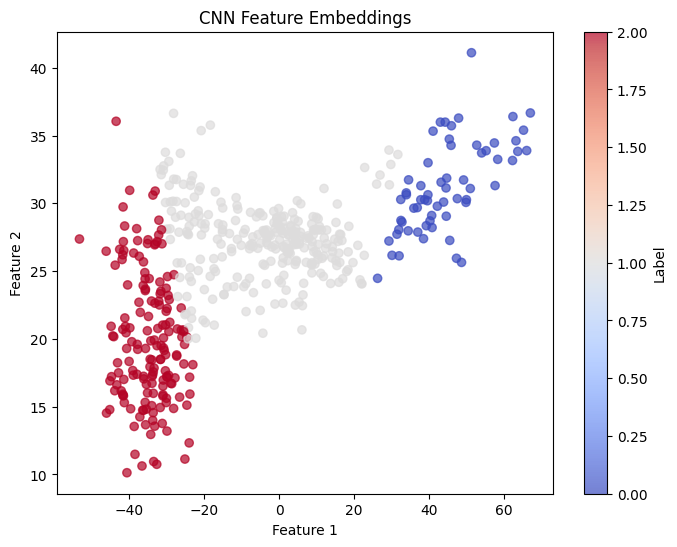

In [4]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import label_binarize

# Load dataset
df = pd.read_csv("labelled_dysx.csv")
X = df[['Language_vocab','Memory','Speed','Visual_discrimination','Audio_Discrimination','Survey_Score']].values
y = df['Label'].values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert to torch tensors
X_tensor = torch.tensor(X, dtype=torch.float).unsqueeze(1)
y_tensor = torch.tensor(y, dtype=torch.long)

# CNN Model
class CNN1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=2)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=2)
        self.fc = nn.Linear(32*(X.shape[1]-2), 16)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = CNN1D()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

# Training CNN
for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    out = model(X_tensor)
    loss = loss_fn(out, y_tensor)
    loss.backward()
    optimizer.step()

# Extract CNN embeddings
model.eval()
with torch.no_grad():
    embeddings = model(X_tensor).numpy()

# Split for SVM
X_train, X_test, y_train, y_test = train_test_split(embeddings, y, test_size=0.2, random_state=42)

# Train SVM
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve for multiclass
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {cls} (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], '--', color='gray')
plt.title("Multiclass ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# CNN Embedding distribution plot
plt.figure(figsize=(8,6))
plt.scatter(embeddings[:,0], embeddings[:,1], c=y, cmap='coolwarm', alpha=0.7)
plt.title("CNN Feature Embeddings")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label='Label')
plt.show()


In [5]:
import joblib

# --- Save CNN model ---
torch.save(model.state_dict(), "cnn_model.pth")

# --- Save SVM model ---
joblib.dump(svm, "svm_model.pkl")

# --- Later, to load the models ---

# Load CNN
loaded_cnn = CNN1D()
loaded_cnn.load_state_dict(torch.load("cnn_model.pth"))
loaded_cnn.eval()

# Load SVM
loaded_svm = joblib.load("svm_model.pkl")

# Example: get CNN embeddings for new data
with torch.no_grad():
    new_embeddings = loaded_cnn(X_tensor).numpy()

# Predict with loaded SVM
new_preds = loaded_svm.predict(new_embeddings)
